<a href="https://colab.research.google.com/github/innocenti2010/Data-Scientist-Portfolio/blob/main/Python-Projects/%F0%9F%93%A6%20Cross-Selling-Insurance-ML/Cross_Selling_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIMENSIONI DATASET
(381109, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 381109 entries, 1 to 381109
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                381109 non-null  object 
 1   Age                   381109 non-null  int64  
 2   Driving_License       381109 non-null  int64  
 3   Region_Code           381109 non-null  float64
 4   Previously_Insured    381109 non-null  int64  
 5   Vehicle_Age           381109 non-null  object 
 6   Vehicle_Damage        381109 non-null  object 
 7   Annual_Premium        381109 non-null  float64
 8   Policy_Sales_Channel  381109 non-null  float64
 9   Vintage               381109 non-null  int64  
 10  Response              381109 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 34.9+ MB
None
                 Age  Driving_License    Region_Code  Previously_Insured  \
count  381109.000000    381109.000000  381

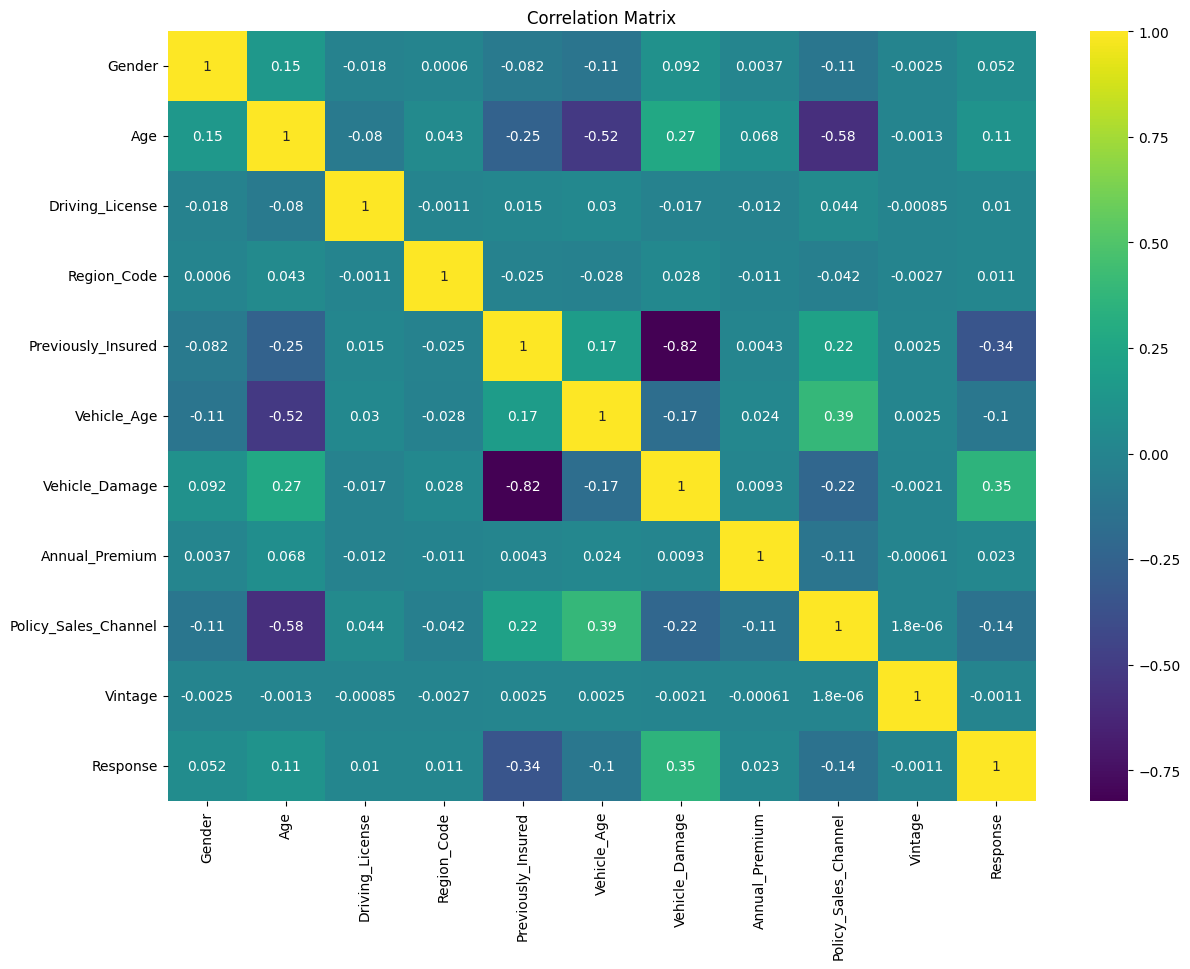


=== LOGISTIC REGRESSION — TRAIN ===
========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.99      0.59      0.74    250799
           1       0.25      0.98      0.40     35032

    accuracy                           0.64    285831
   macro avg       0.62      0.78      0.57    285831
weighted avg       0.90      0.64      0.70    285831

Accuracy: 0.6386
AUC: 0.8191


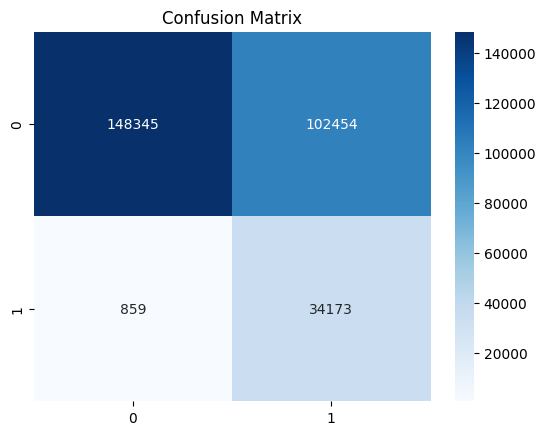

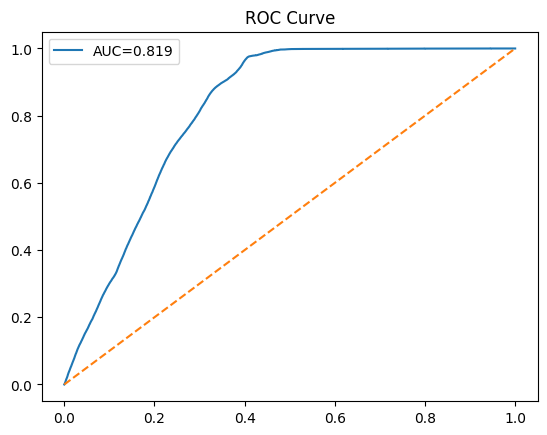


=== LOGISTIC REGRESSION — TEST ===
========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     83600
           1       0.25      0.98      0.40     11678

    accuracy                           0.64     95278
   macro avg       0.62      0.79      0.57     95278
weighted avg       0.90      0.64      0.70     95278

Accuracy: 0.6414
AUC: 0.8216


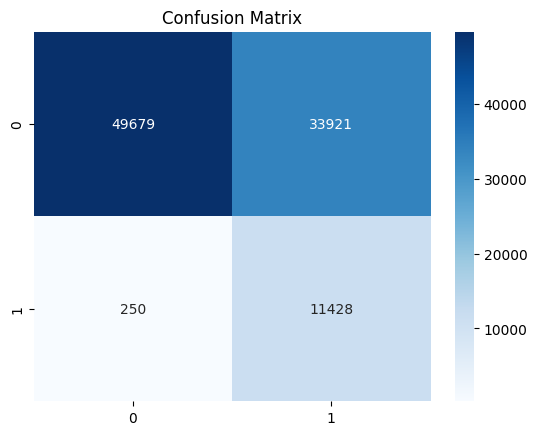

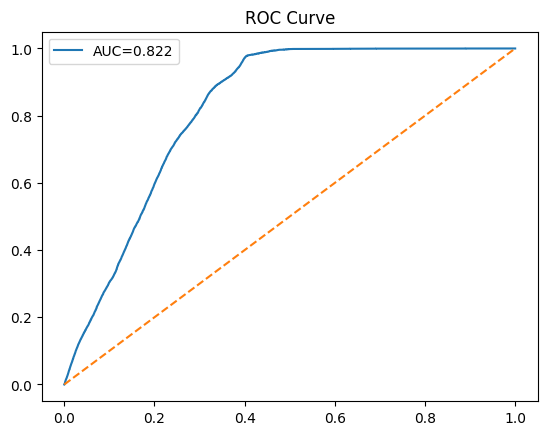


=== OVERSAMPLING — TRAIN ===
========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.96      0.59      0.73    250799
           1       0.70      0.98      0.82    250799

    accuracy                           0.78    501598
   macro avg       0.83      0.78      0.78    501598
weighted avg       0.83      0.78      0.78    501598

Accuracy: 0.7836
AUC: 0.8190


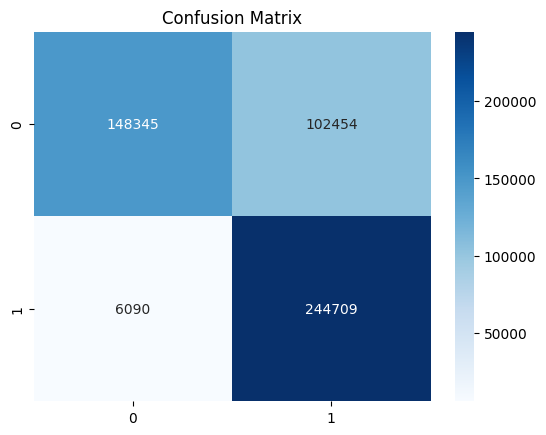

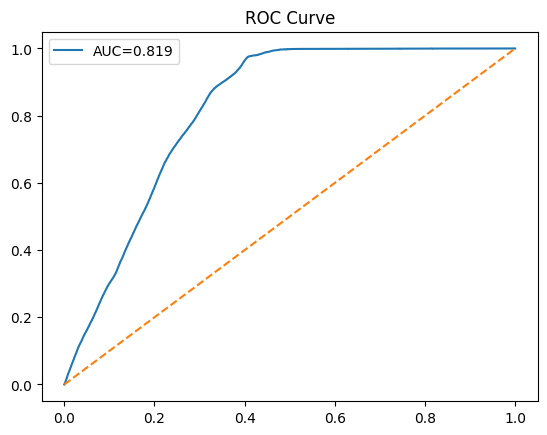


=== OVERSAMPLING — TEST ===
========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     83600
           1       0.25      0.98      0.40     11678

    accuracy                           0.64     95278
   macro avg       0.62      0.79      0.57     95278
weighted avg       0.90      0.64      0.70     95278

Accuracy: 0.6414
AUC: 0.8214


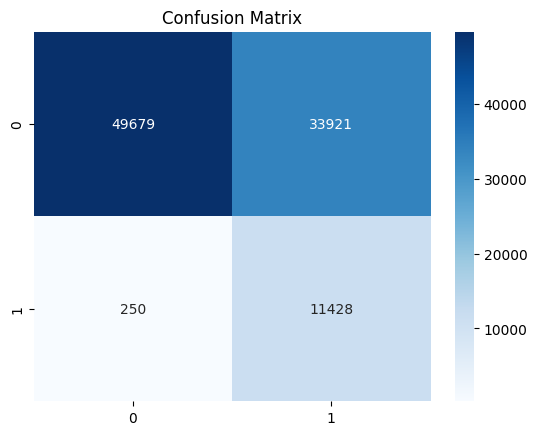

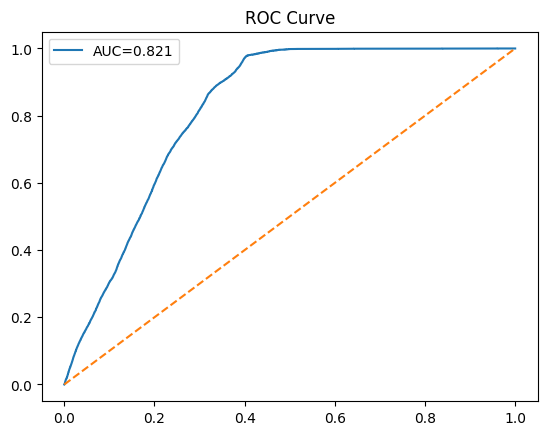


=== UNDERSAMPLING — TRAIN ===
========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.96      0.59      0.73     35032
           1       0.71      0.98      0.82     35032

    accuracy                           0.79     70064
   macro avg       0.83      0.79      0.78     70064
weighted avg       0.83      0.79      0.78     70064

Accuracy: 0.7851
AUC: 0.8194


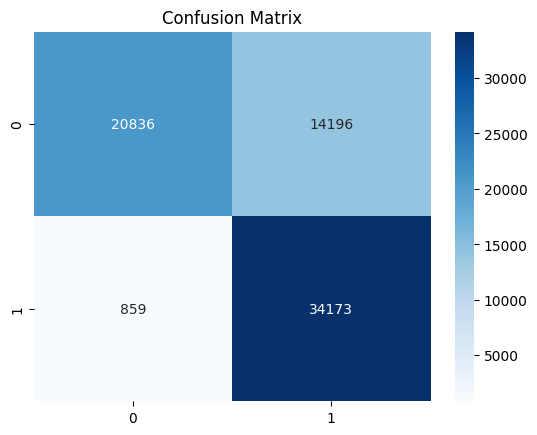

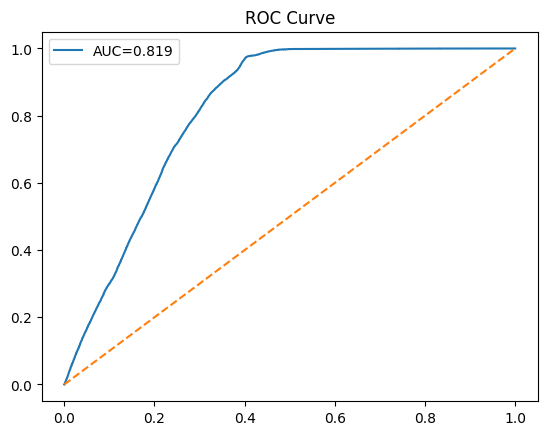


=== UNDERSAMPLING — TEST ===
========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     83600
           1       0.25      0.98      0.40     11678

    accuracy                           0.64     95278
   macro avg       0.62      0.79      0.57     95278
weighted avg       0.90      0.64      0.70     95278

Accuracy: 0.6414
AUC: 0.8213


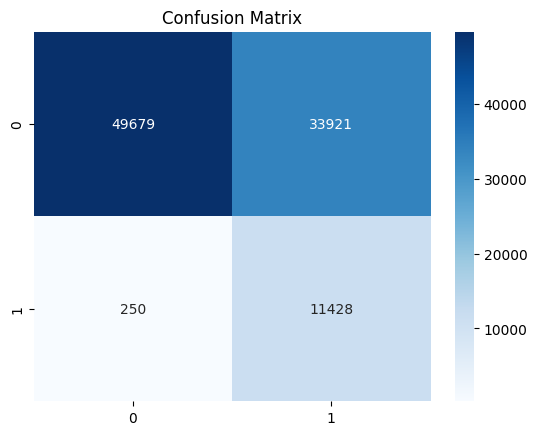

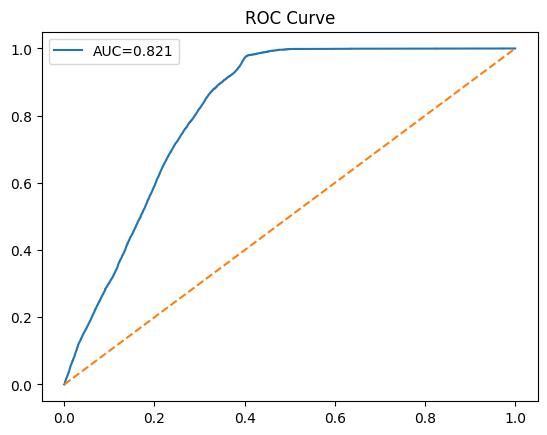


MODELLO FINALE SELEZIONATO: Logistic Regression (class_weight='balanced')


In [3]:
# ============================================================
#  CROSS-SELLING ASSICURATIVO — MODELLO PREDITTIVO
#  Autore: Francesco Innocenti
#  Obiettivo: Predire l'interesse dei clienti verso una polizza auto
# ============================================================

# ============================
# 1. IMPORT LIBRARIES
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter


# ============================
# 2. LOAD DATASET
# ============================

df = pd.read_csv("/content/insurance_cross_sell.csv", index_col=0)

print("DIMENSIONI DATASET")
print(df.shape)
print(df.info())
print(df.describe())


# ============================
# 3. DATA CLEANING & ENCODING
# ============================

df_copy = df.copy().reset_index(drop=True)

gender_mapping = {'Female': 0, 'Male': 1}
age_mapping = {'1-2 Year': 1, '< 1 Year': 2, '> 2 Years': 3}
damage_mapping = {'No': 0, 'Yes': 1}

df_copy['Gender'] = df_copy['Gender'].map(gender_mapping)
df_copy['Vehicle_Age'] = df_copy['Vehicle_Age'].map(age_mapping)
df_copy['Vehicle_Damage'] = df_copy['Vehicle_Damage'].map(damage_mapping)

df_copy['Age'] = pd.to_numeric(df_copy['Age'], errors='coerce')
df_copy['Age'] = df_copy['Age'].fillna(df_copy['Age'].median())

# Drop rows where 'Response' is NaN, as train_test_split does not handle them
df_copy.dropna(subset=['Response'], inplace=True)


# ============================
# 4. CORRELATION ANALYSIS
# ============================

plt.figure(figsize=(14, 10), dpi=100)
sns.heatmap(df_copy.corr(), annot=True, cmap="viridis")
plt.title("Correlation Matrix")
plt.show()


# ============================
# 5. TRAIN/TEST SPLIT
# ============================

X = df_copy.drop("Response", axis=1).values
y = df_copy["Response"].values

X_short = df_copy[["Previously_Insured", "Vehicle_Damage",
                   "Policy_Sales_Channel", "Age"]].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y
)

X_short_train, X_short_test, y_short_train, y_short_test = train_test_split(
    X_short, y, stratify=y
)


# ============================
# 6. STANDARDIZATION
# ============================

ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

X_short_train = ss.fit_transform(X_short_train)
X_short_test = ss.transform(X_short_test)


# ============================
# 7. OVERSAMPLING & UNDERSAMPLING
# ============================

oversample = RandomOverSampler(sampling_strategy='minority')
X_over, y_over = oversample.fit_resample(X_train, y_train)
X_short_over, y_short_over = oversample.fit_resample(X_short_train, y_short_train)

undersample = RandomUnderSampler(sampling_strategy='majority')
X_under, y_under = undersample.fit_resample(X_train, y_train)
X_short_under, y_short_under = undersample.fit_resample(X_short_train, y_short_train)


# ============================
# 8. MODEL EVALUATION FUNCTION
# ============================

def evaluate_model(model, data, labels=('NO', 'YES')):
    X, y = data
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    print("========== CLASSIFICATION REPORT ==========")
    print(classification_report(y, y_pred))

    acc = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)

    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")

    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y, y_proba)
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


# ============================
# 9. LOGISTIC REGRESSION
# ============================

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

print("\n=== LOGISTIC REGRESSION — TRAIN ===")
evaluate_model(lr, (X_train, y_train))

print("\n=== LOGISTIC REGRESSION — TEST ===")
evaluate_model(lr, (X_test, y_test))


# ============================
# 10. OVERSAMPLING MODEL
# ============================

lr_over = LogisticRegression(class_weight='balanced')
lr_over.fit(X_over, y_over)

print("\n=== OVERSAMPLING — TRAIN ===")
evaluate_model(lr_over, (X_over, y_over))

print("\n=== OVERSAMPLING — TEST ===")
evaluate_model(lr_over, (X_test, y_test))


# ============================
# 11. UNDERSAMPLING MODEL
# ============================

lr_under = LogisticRegression(class_weight='balanced')
lr_under.fit(X_under, y_under)

print("\n=== UNDERSAMPLING — TRAIN ===")
evaluate_model(lr_under, (X_under, y_under))

print("\n=== UNDERSAMPLING — TEST ===")
evaluate_model(lr_under, (X_test, y_test))


# ============================
# 12. MODEL SELECTION
# ============================

print("\nMODELLO FINALE SELEZIONATO: Logistic Regression (class_weight='balanced')")